# API Data Wrangling with Open-Meteo

In this exercise, we will:

- Fetch historical weather data using the **Open-Meteo API**.
- Parse and clean the data using **pandas**.
- Perform exploratory data analysis.
- Visualize weather trends.

In [1]:
# Install required packages if not already installed
# !pip install requests pandas matplotlib --quiet
!pip install requests pandas matplotlib --quiet

In [2]:
# Import Libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Optional: Configure matplotlib for inline display in Jupyter
%matplotlib inline

## Understand the Open-Meteo API

- **API Endpoint**: `https://archive-api.open-meteo.com/v1/archive`
- **Parameters**:
  - `latitude`: Latitude of the location.
  - `longitude`: Longitude of the location.
  - `start_date`: Start date of the data (YYYY-MM-DD).
  - `end_date`: End date of the data (YYYY-MM-DD).
  - `hourly`: Comma-separated list of variables (e.g., temperature, precipitation).
  - `timezone`: Timezone of the data.

**Documentation**: [Open-Meteo API Docs](https://open-meteo.com/en/docs)

In [ ]:
# Step 1: Set Up Parameters

# Location coordinates for New York City
latitude = 40.7128
longitude = -74.0060

# Date range
start_date = '2023-01-01'
end_date = '2023-01-07'  # One week of data

# Variables to fetch
hourly_variables = ['temperature_2m', 'relativehumidity_2m', 'precipitation']


In [ ]:
# Step 2: Make the API Request

base_url = 'https://archive-api.open-meteo.com/v1/archive'

params = {
    'latitude': latitude,
    'longitude': longitude,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'America/New_York'
}

response = requests.get(base_url, params=params)


In [ ]:
# Check if the request was successful

if response.status_code == 200:
    print('Data fetched successfully!')
else:
    print(f'Failed to fetch data. Status code: {response.status_code}')


Data fetched successfully!


In [ ]:
# Step 3: Load Data into pandas DataFrame

data = response.json()
hourly_data = data['hourly']

df = pd.DataFrame(hourly_data)
df.head()


,time,temperature_2m,relativehumidity_2m,precipitation
0,2023-01-01T00:00,10.9,99,1.0
1,2023-01-01T01:00,10.6,99,1.0
2,2023-01-01T02:00,10.6,98,0.1
3,2023-01-01T03:00,10.4,96,0.0
4,2023-01-01T04:00,9.8,95,0.0


In [ ]:
# Step 4: Data Cleaning

# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])

# Set 'time' as the index
df.set_index('time', inplace=True)

# Check for missing values
df.isnull().sum()


,0
temperature_2m,0
relativehumidity_2m,0
precipitation,0


In [ ]:
df.head()

,temperature_2m,relativehumidity_2m,precipitation
time,,,
2023-01-01 00:00:00,10.9,99,1.0
2023-01-01 01:00:00,10.6,99,1.0
2023-01-01 02:00:00,10.6,98,0.1
2023-01-01 03:00:00,10.4,96,0.0
2023-01-01 04:00:00,9.8,95,0.0


In [ ]:
# Handle missing values (if any)
df.fillna(method='ffill', inplace=True)  # Forward fill


/tmp/ipykernel_8292/1928920962.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)  # Forward fill


In [ ]:
# Step 5: Exploratory Data Analysis

# Summary Statistics
df.describe()

,temperature_2m,relativehumidity_2m,precipitation
count,168.000000,168.000000,168.000000
mean,8.501190,86.422619,0.142857
std,3.494598,12.799933,0.436037
min,0.500000,45.000000,0.000000
25%,6.100000,81.000000,0.000000
50%,8.400000,90.500000,0.000000
75%,11.200000,97.000000,0.000000
max,18.000000,100.000000,3.100000


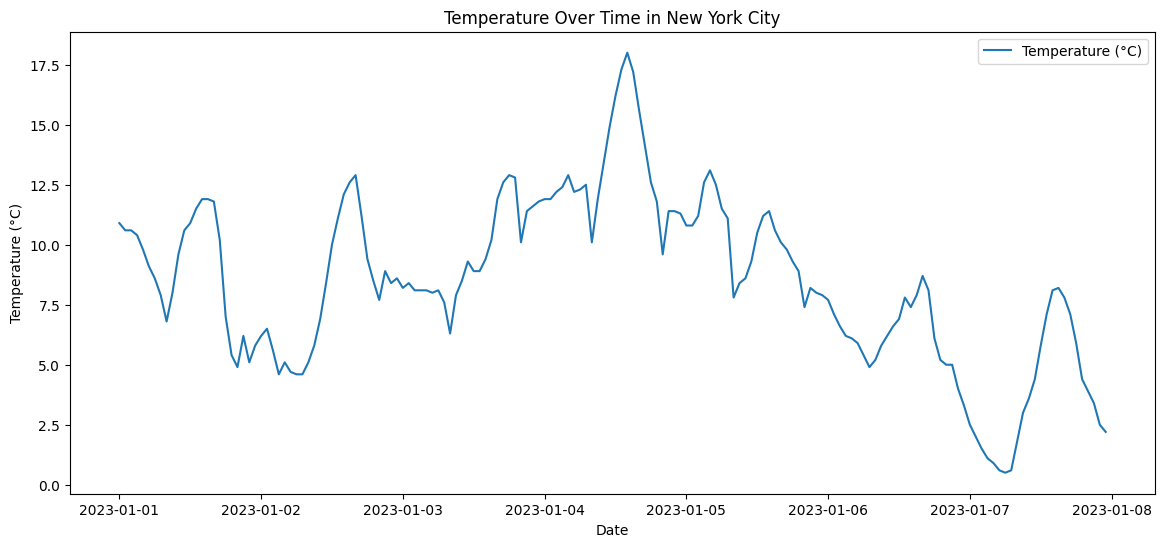

In [ ]:
# Plot Temperature Over Time

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['temperature_2m'], label='Temperature (°C)')
plt.title('Temperature Over Time in New York City')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

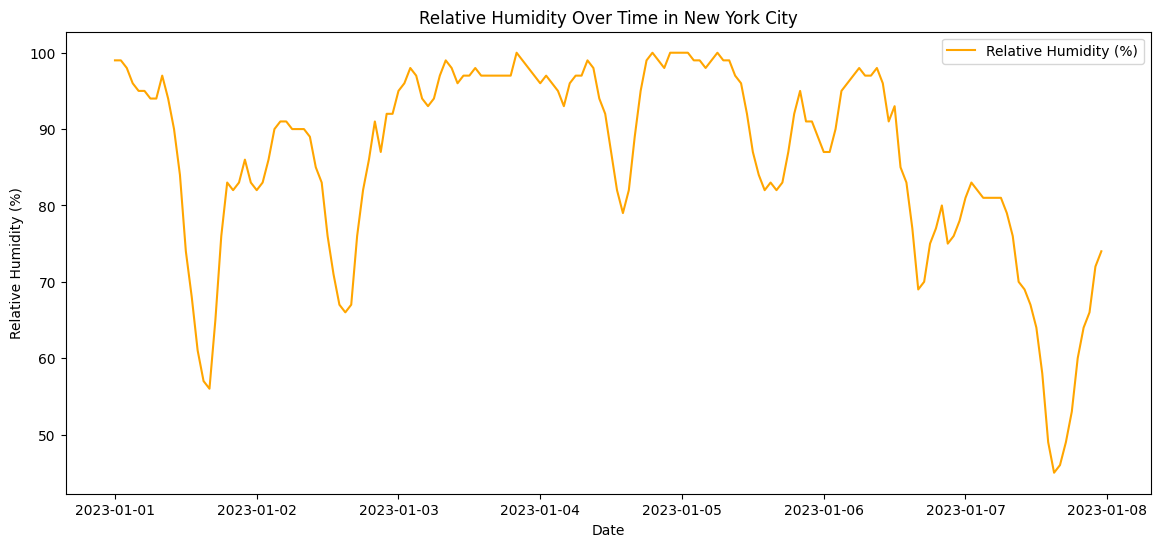

In [ ]:
# Plot Relative Humidity Over Time

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['relativehumidity_2m'], color='orange', label='Relative Humidity (%)')
plt.title('Relative Humidity Over Time in New York City')
plt.xlabel('Date')
plt.ylabel('Relative Humidity (%)')
plt.legend()
plt.show()


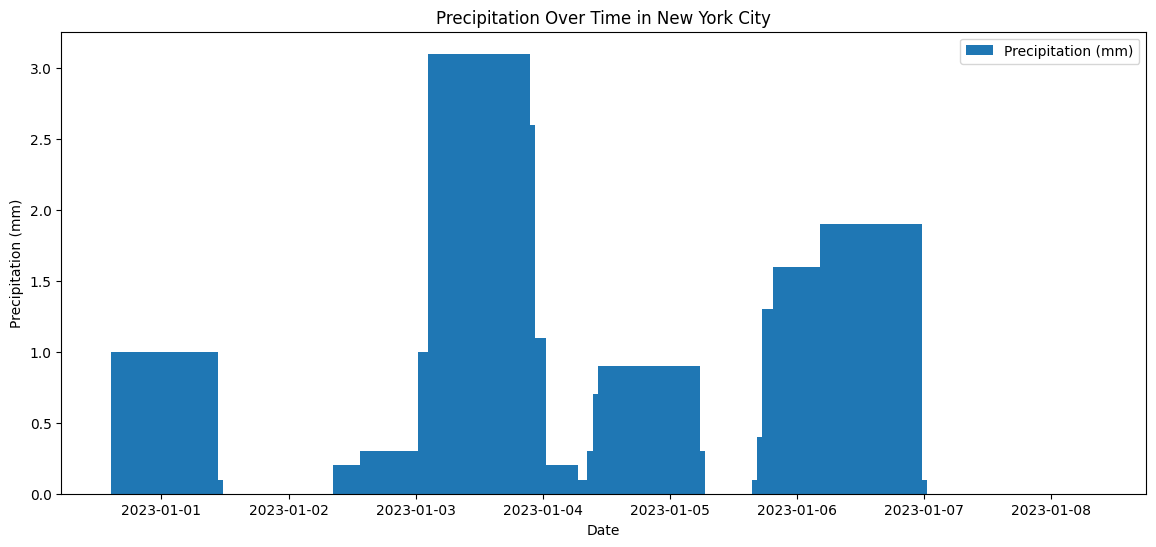

In [ ]:
# Plot Precipitation Over Time

plt.figure(figsize=(14, 6))
plt.bar(df.index, df['precipitation'], label='Precipitation (mm)')
plt.title('Precipitation Over Time in New York City')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.show()


In [ ]:
# Step 6: Correlation Analysis

# Calculate correlation between temperature and humidity
correlation = df['temperature_2m'].corr(df['relativehumidity_2m'])
print(f'Correlation between Temperature and Relative Humidity: {correlation:.2f}')


Correlation between Temperature and Relative Humidity: 0.24


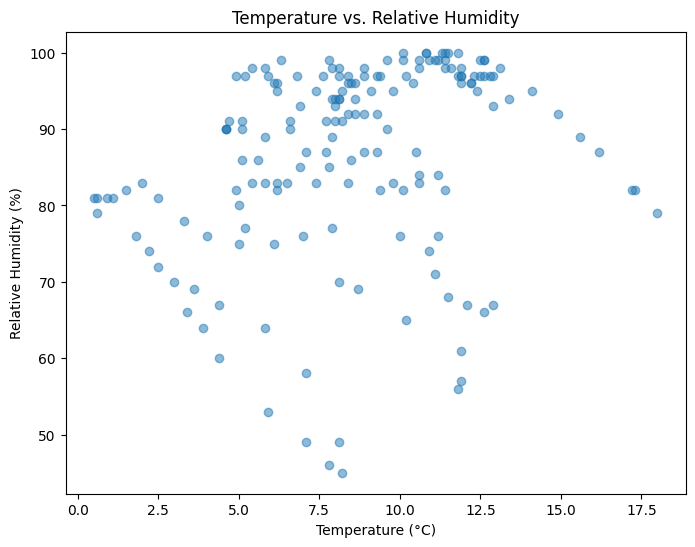

In [ ]:
# Scatter Plot of Temperature vs. Relative Humidity

plt.figure(figsize=(8, 6))
plt.scatter(df['temperature_2m'], df['relativehumidity_2m'], alpha=0.5)
plt.title('Temperature vs. Relative Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()


In [ ]:
# Step 7: Resample Data to Daily Averages

daily_avg = df.resample('D').mean()
daily_avg.head()


,temperature_2m,relativehumidity_2m,precipitation
time,,,
2023-01-01,8.979167,83.708333,0.087500
2023-01-02,7.895833,83.458333,0.020833
2023-01-03,9.545833,96.875000,0.395833
2023-01-04,13.129167,94.166667,0.095833
2023-01-05,10.041667,92.666667,0.000000


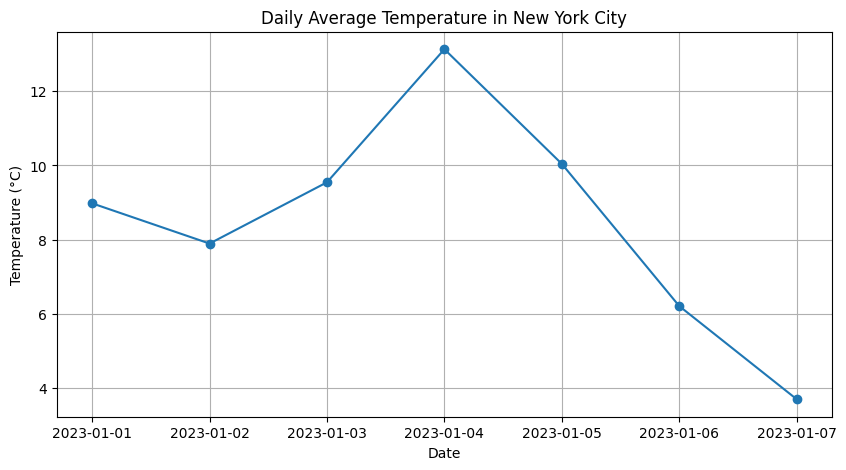

In [ ]:
# Plot Daily Average Temperature

plt.figure(figsize=(10, 5))
plt.plot(daily_avg.index, daily_avg['temperature_2m'], marker='o')
plt.title('Daily Average Temperature in New York City')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()


In [ ]:
# Step 8: Compare with Another Location (Los Angeles)

# Coordinates for Los Angeles
latitude_la = 34.0522
longitude_la = -118.2437

params_la = {
    'latitude': latitude_la,
    'longitude': longitude_la,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'America/Los_Angeles'
}

response_la = requests.get(base_url, params=params_la)

# Load and clean Los Angeles data
data_la = response_la.json()
hourly_data_la = data_la['hourly']
df_la = pd.DataFrame(hourly_data_la)

df_la['time'] = pd.to_datetime(df_la['time'])
df_la.set_index('time', inplace=True)
df_la.fillna(method='ffill', inplace=True)


/tmp/ipykernel_8292/4259999984.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_la.fillna(method='ffill', inplace=True)


In [ ]:
# Resample Los Angeles Data to Daily Averages

daily_avg_la = df_la.resample('D').mean()


In [ ]:
# Combine DataFrames for Comparison

combined_temp = pd.DataFrame({
    'New York': daily_avg['temperature_2m'],
    'Los Angeles': daily_avg_la['temperature_2m']
})


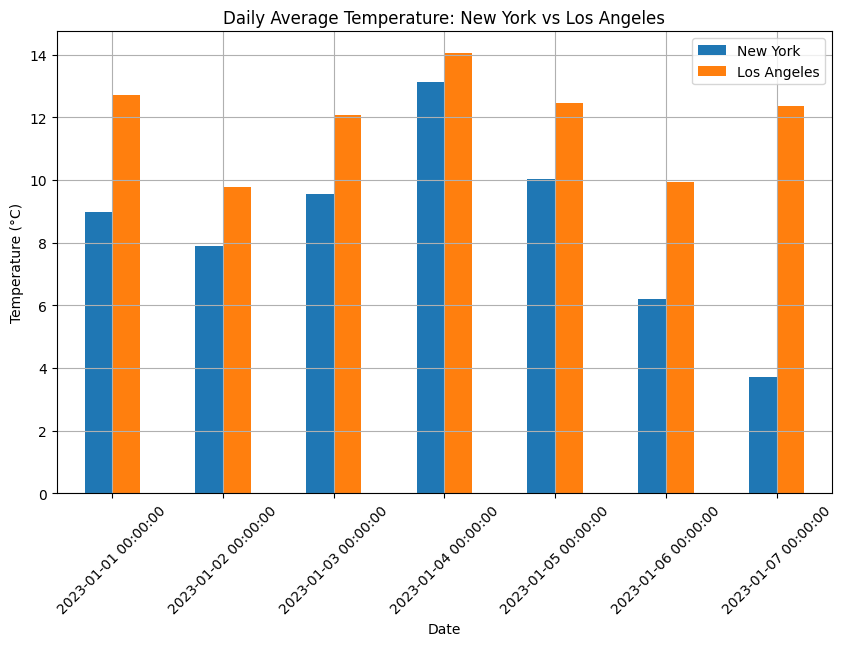

In [ ]:
# Plot Comparison of Daily Average Temperature

combined_temp.plot(kind='bar', figsize=(10, 6))
plt.title('Daily Average Temperature: New York vs Los Angeles')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [ ]:
combined_temp.head()

,New York,Los Angeles
time,,
2023-01-01,8.979167,12.704167
2023-01-02,7.895833,9.762500
2023-01-03,9.545833,12.079167
2023-01-04,13.129167,14.037500
2023-01-05,10.041667,12.454167


In [ ]:
# Step 9: Advanced Analysis - Temperature Difference

# Calculate Temperature Difference
combined_temp['Temp Difference'] = combined_temp['Los Angeles'] - combined_temp['New York']
combined_temp


,New York,Los Angeles,Temp Difference
time,,,
2023-01-01,8.979167,12.704167,3.725000
2023-01-02,7.895833,9.762500,1.866667
2023-01-03,9.545833,12.079167,2.533333
2023-01-04,13.129167,14.037500,0.908333
2023-01-05,10.041667,12.454167,2.412500
2023-01-06,6.212500,9.929167,3.716667
2023-01-07,3.704167,12.366667,8.662500


In [ ]:
# Step 10: Save Data to CSV (Optional)

# Save New York data
df.to_csv('new_york_weather.csv')

# Save Los Angeles data
df_la.to_csv('los_angeles_weather.csv')

#Save combined_temp as well:
combined_temp.to_csv('NYC_vs_LA_weather.csv')

## Conclusion

In this exercise, we:

- Accessed and retrieved data from the **Open-Meteo API**.
- Cleaned and preprocessed JSON data using **pandas**.
- Performed exploratory data analysis and visualization.
- Compared weather patterns between **New York City** and **Los Angeles**.

---

**Next Steps**:

- **Extend the Date Range**: Analyze seasonal trends by fetching data over several months.
- **Fetch Additional Variables**: Include wind speed, atmospheric pressure, or other interesting variables.
- **Forecasting**: Use statistical methods or machine learning models to forecast future weather patterns.
- **Global Analysis**: Compare data from other global cities to gain broader insights.


## Exercises for Students

Now it's your turn! Below are some exercises to reinforce what you've learned. Try to complete them without looking at the solutions.

### Exercise: Compare Rainfall Between London and Seattle

- **Objective**: Compare the total weekly rainfall between London and Seattle over a full year.
- **Tasks**:
  1. **Fetch Data**: Retrieve hourly precipitation data for London and Seattle for the year 2022.
     - **London Coordinates**: Latitude `51.5074`, Longitude `-0.1278`
     - **Seattle Coordinates**: Latitude `47.6062`, Longitude `-122.3321`
  2. **Data Cleaning**: Convert the time columns to datetime objects and set them as the index. Handle any missing values.
  3. **Resample Data**: Resample the hourly data to weekly totals.
  4. **Visualization**: Plot the weekly total precipitation for both cities on the same graph.
  5. **Analysis**: Determine which city had more rainfall overall and identify any interesting patterns.

**Note**: Remember to handle any API limitations, such as data availability or rate limits, and to be mindful of the size of the data you're requesting.

### Tips:

- **API Parameters**: Make sure to adjust the parameters like `latitude`, `longitude`, `start_date`, `end_date`, `hourly`, and `timezone` as needed.
- **Error Handling**: Always check if your API requests are successful before proceeding.
- **Data Storage**: Consider saving your DataFrames to CSV files for future analysis.
- **Visualization**: Customize your plots with titles, labels, legends, and gridlines for better readability.

Happy coding!


In [3]:
#step1: setup parameters

London_latitude = 51.5074
London_longitude = -0.1278

Seattle_latitude = 47.6062
Seattle_longitude = -122.3321

start_date = '2022-01-01'
end_date = '2022-12-31'

hourly_variables = ['precipitation']

In [4]:
#step2: make the API request

url = 'https://archive-api.open-meteo.com/v1/archive'

params_London = {
    'latitude': London_latitude,
    'longitude': London_longitude,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'Europe/London'
}

params_Seattle = {
    'latitude': Seattle_latitude,
    'longitude': Seattle_longitude,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'America/Los_Angeles'
}



response_London = requests.get(url, params = params_London)
response_Seattle = requests.get(url, params = params_Seattle)

In [5]:
#step2.5: check to see if API fetch is successful

if response_London.status_code == 200 and response_Seattle.status_code == 200:
  print('Data fetched successfully!')
else:
  print(f'Failed to fetch data. Status code: {response_London.status_code}, {response_Seattle.status_code}')

Data fetched successfully!


In [6]:
#step3: load data from API into pandas DataFrame

data_London = response_London.json()
hourly_data_London = data_London['hourly']
df_London = pd.DataFrame(hourly_data_London)


data_Seattle = response_Seattle.json()
hourly_data_Seattle = data_Seattle['hourly']
df_Seattle = pd.DataFrame(hourly_data_Seattle)

In [7]:
df_London.head()

,time,precipitation
0,2022-01-01T00:00,0.0
1,2022-01-01T01:00,0.0
2,2022-01-01T02:00,0.0
3,2022-01-01T03:00,0.0
4,2022-01-01T04:00,0.0


In [8]:
df_Seattle.head()

,time,precipitation
0,2022-01-01T00:00,0.0
1,2022-01-01T01:00,0.0
2,2022-01-01T02:00,0.0
3,2022-01-01T03:00,0.0
4,2022-01-01T04:00,0.0


In [12]:
#step4: data cleaning

df_London['time'] = pd.to_datetime(df_London['time'])
df_London.set_index('time', inplace=True)
df_London.head()

,precipitation
time,
2022-01-01 00:00:00,0.0
2022-01-01 01:00:00,0.0
2022-01-01 02:00:00,0.0
2022-01-01 03:00:00,0.0
2022-01-01 04:00:00,0.0


In [13]:
df_Seattle['time'] = pd.to_datetime(df_Seattle['time'])
df_Seattle.set_index('time', inplace=True)
df_Seattle.head()

,precipitation
time,
2022-01-01 00:00:00,0.0
2022-01-01 01:00:00,0.0
2022-01-01 02:00:00,0.0
2022-01-01 03:00:00,0.0
2022-01-01 04:00:00,0.0


In [14]:
df_London.isnull().sum()

,0
precipitation,0


In [15]:
df_Seattle.isnull().sum()

,0
precipitation,0


In [16]:
df_London.fillna(method='ffill', inplace=True)
df_Seattle.fillna(method='ffill', inplace=True)

/tmp/ipykernel_1798/3498125384.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_London.fillna(method='ffill', inplace=True)
/tmp/ipykernel_1798/3498125384.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_Seattle.fillna(method='ffill', inplace=True)


In [17]:
#step5: exploratory data analysis

df_London.describe()

,precipitation
count,8760.000000
mean,0.075696
std,0.404506
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,14.700000


In [18]:
df_Seattle.describe()

,precipitation
count,8760.000000
mean,0.129132
std,0.463708
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,7.700000


In [20]:
#resampling from hourly to weekly

London_df_weekly = df_London.resample('W').mean()
Seattle_df_weekly = df_Seattle.resample('W').mean()

In [24]:
#combining seattle and london tables

London_Seattle_df_weekly = pd.DataFrame({'London': London_df_weekly['precipitation'], 'Seattle': Seattle_df_weekly['precipitation']})

In [25]:
London_Seattle_df_weekly.head()

,London,Seattle
time,,
2022-01-02,0.045833,0.652083
2022-01-09,0.076786,0.647619
2022-01-16,0.018452,0.270833
2022-01-23,0.000000,0.093452
2022-01-30,0.002381,0.036310


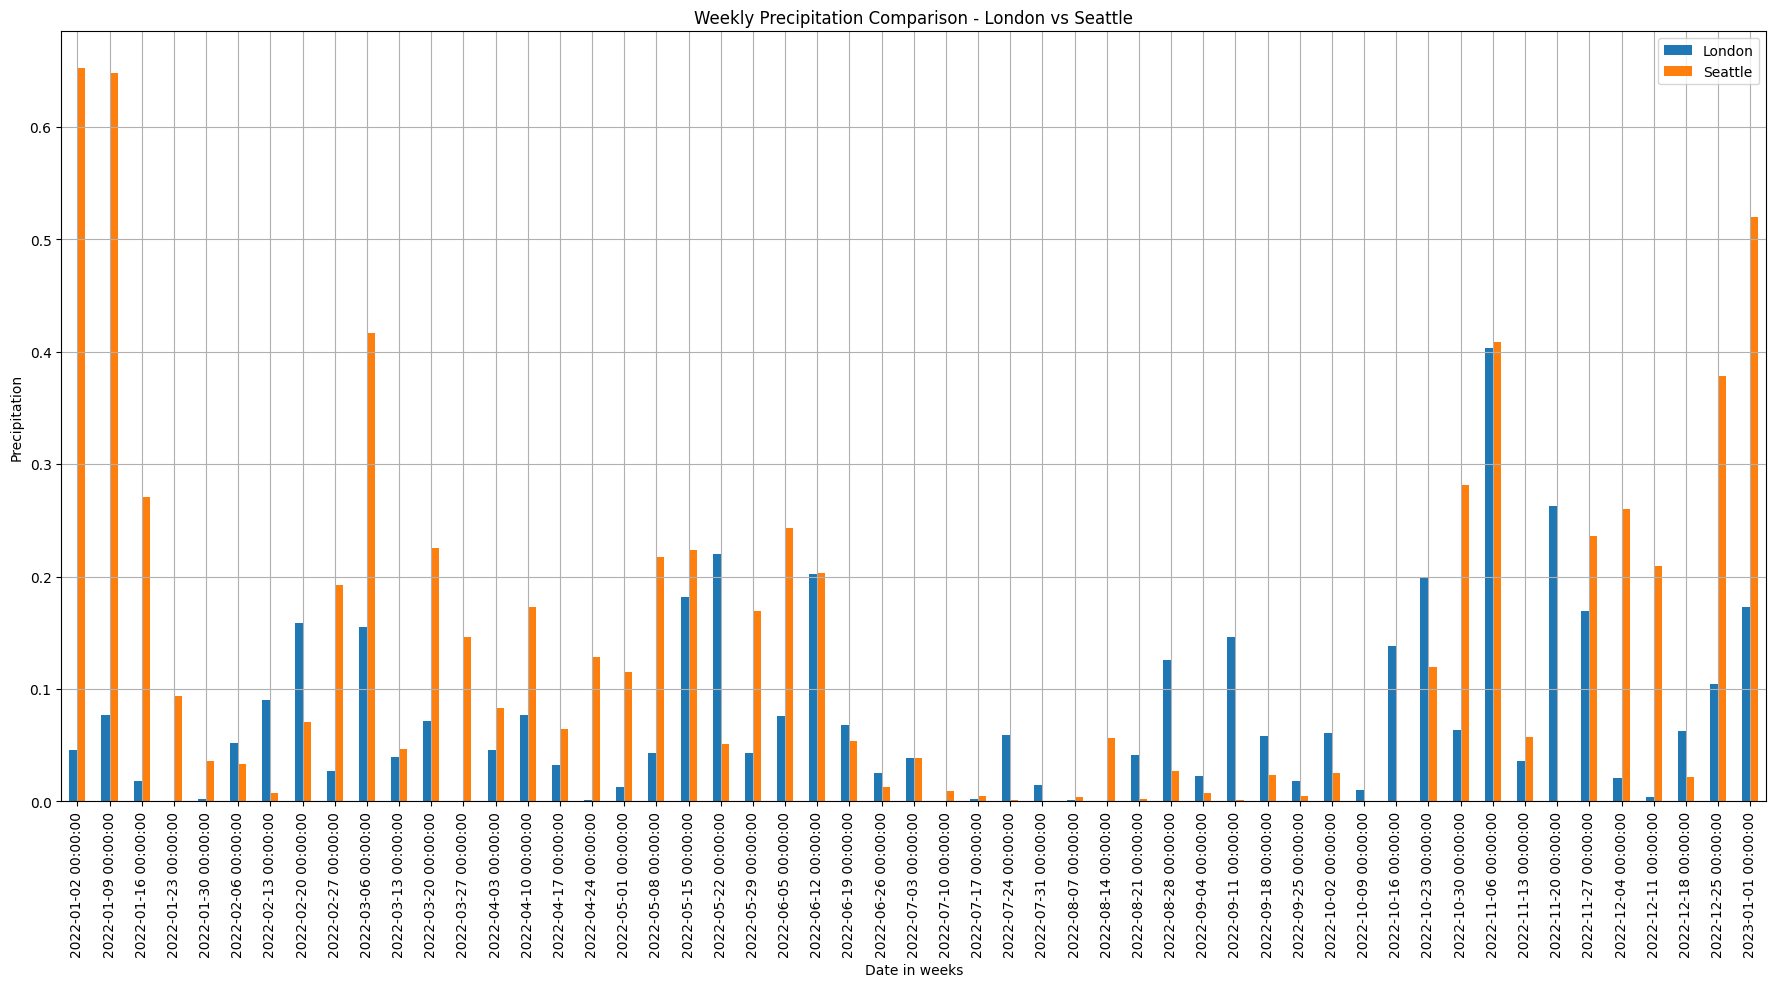

In [43]:
#plot a bar-chart for comparison

weekly_comparison = London_Seattle_df_weekly
weekly_comparison.plot(kind='bar', figsize=(22,10))
plt.title('Weekly Precipitation Comparison - London vs Seattle')
plt.xlabel('Date in weeks')
plt.ylabel('Precipitation')
plt.legend()
plt.grid(True)
plt.show()


In [44]:
#step6: saveing the data as csv file

London_Seattle_df_weekly.to_csv('London_Seattle_Precipitation_Weekly.csv')


Conclusion of this comparison between Seattle and London:
Generally, Seattle is rainier than London. Seattle has much more rain in the beginning of January. It is also ranier at March and April.
However, London is rainier during September and October. Both cities have almost same amount on precipitation during the weeks in summer season.